In [1]:
fileName = "janus_cal_sc_0777417466_0096_03_20240819T212236_0020__1_0.xml"
import os

os.environ["ISISDATA"] = "/data/isis_data"
os.environ["ISISTESTDATA"] = "//data/isis_data/test_data"
os.environ["ISISROOT"] = "/home/luca/Code/isis_and_co/ISIS3.git/build"
# USGSCSM_LOG_FILE environment variable to the file the log should be written to. To have the logging information printed to the standard output or standard error, set this to stdout or stderr.

# You can adjust how much information is logged by setting the USGSCSM_LOG_LEVEL en


os.environ["USGSCSM_LOG_FILE"] = "stdout"
os.environ["USGSCSM_LOG_LEVEL"] = "debug"

import ale
from ale.drivers.osirisrex_drivers import OsirisRexCameraIsisLabelNaifSpiceDriver
from ale.drivers.juice_drivers import (
    JuicePds4LabelNaifSpiceDriver,
    JuicePds4LabelNaifSpiceDriverPush,
)
from ale.formatters.formatter import to_isd
import spiceypy as spice
from ale.drivers import AleJsonEncoder

In [2]:
# from ale.util import generate_kernels_from_cube
# kernels = generate_kernels_from_cube(fileName, expand=True, format_as='list')

In [3]:
kernels = ['/data/JUICE.git/kernels/mk/juice_ops_local.tm']
# kernels = ['/data/JUICE.git/kernels/mk/juice_plan_local.tm']

In [4]:
from ale.base.label_pds4 import Pds4Label

In [5]:
# JUICE_SPACECRAFT           J2000                  SWITCH          -28000
# JUICE_SPACECRAFT_PLAN      J2000                  CK              -28001
# JUICE_SPACECRAFT_MEAS      J2000                  CK              -28002


In [6]:
with JuicePds4LabelNaifSpiceDriverPush(fileName, props = {"kernels": kernels}) as driver:
    # chain = driver.frame_chain
    isisString = to_isd(driver)



[-28200] -28200
Frame -28200 is of type 4 and is attached to -28000
[[ 9.99998347e-01 -2.39952367e-09 -1.81804977e-03]
 [ 1.51843394e-06  9.99999652e-01  8.33878109e-04]
 [ 1.81804914e-03 -8.33879492e-04  9.99998000e-01]] -28000 6
Frame -28000 is a switch frame. Trying to detect the right underlaying kernel
JUICE_SPACECRAFT_MEAS
3
Correctly resolved matrix [[ 0.83881114  0.09572562  0.53594074]
 [-0.49944367  0.52710884  0.68754075]
 [-0.21668384 -0.84438905  0.48995432]] for frame of type 1. Returning
Frame -28000 is of type 6 and is attached to -28002
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]] -28002 3
Frame -28002 is of type 3 and is attached to 1
[[ 0.83881114  0.09572562  0.53594074]
 [-0.49944367  0.52710884  0.68754075]
 [-0.21668384 -0.84438905  0.48995432]] 1 1
All frame codes are [-28200, -28000, -28002, 1] for types [4, 6, 3, 1]
Comparing frame type 4
Frame is either 4 or 6. adding as constnat
Comparing frame type 6
Frame is either 4 or 6. adding as constnat
Comparing frame type 3

/home/luca/micromamba/envs/ale/lib/python3.11/site-packages/osgeo/gdal.py:312: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


In [7]:
# with JuicePds4LabelNaifSpiceDriver(fileName, props = {"kernels": kernels}) as driver:

#     # chain = driver.frame_chain
#     isisString = to_isd(driver)

In [8]:
import json

isis_dict = isisString

json_file = os.path.splitext(fileName)[0] + '.json'

In [9]:
import json

isis_dict = isisString

json_file = os.path.splitext(fileName)[0] + '.json'

# with open(json_file, 'w') as fp:
#     json.dump(isis_dict, fp, cls = AleJsonEncoder)
    
with open(json_file, 'r') as fp:
    isis_dict = json.load(fp)
    
isis_dict.keys()

dict_keys(['isis_camera_version', 'image_lines', 'image_samples', 'name_platform', 'name_sensor', 'reference_height', 'name_model', 'starting_ephemeris_time', 'ending_ephemeris_time', 'center_ephemeris_time', 'exposure_duration', 'interframe_delay', 'framelet_order_reversed', 'framelets_flipped', 'framelet_height', 'num_lines_overlap', 'radii', 'body_rotation', 'instrument_pointing', 'naif_keywords', 'detector_sample_summing', 'detector_line_summing', 'focal_length_model', 'detector_center', 'focal2pixel_lines', 'focal2pixel_samples', 'optical_distortion', 'starting_detector_line', 'starting_detector_sample', 'instrument_position', 'sun_position'])

In [10]:
# !csminit from=janus_cal_sc_0777417466_0096_03_20240819T212236_0020__1_0.cub \
#     isd=janus_cal_sc_0777417466_0096_03_20240819T212236_0020__1_0.json \
#     PLUGINNAME=UsgsAstroPluginCSM MODELNAME="USGS_ASTRO_PUSH_FRAME_SENSOR_MODEL"  \
#     TARGETNAME=MOON
# !cam2map from=janus_cal_sc_0777417466_0096_03_20240819T212236_0020__1_0.cub to=janus_cal_sc_0777417466_0096_03_20240819T212236_0020__1_0_proj.cub

In [11]:

from knoten import csm, sensor_utils

In [12]:
# other = '20190303T100344S990_map_iofL2pan_V001-spiceinit.json'

# camera = csm.create_csm(other, verbose=True)

# camera

In [ ]:

camera = csm.create_csm(json_file, verbose=True)
# csm.create_csm(fileName)

In [13]:
camera

<csmapi.csmapi.RasterGM; proxy of <Swig Object of type 'csm::RasterGM *' at 0x7d8db09ec7e0> >

Text(0.5, 1.0, 'CSM footprint')

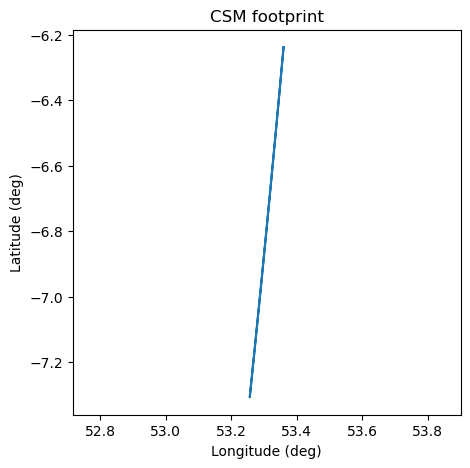

In [14]:
import os
import json
import shapely.wkt
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
from csmapi import csmapi
import pandas as pd

import ale
from knoten import csm, sensor_utils
from knoten.shape import Ellipsoid
from knoten.illuminator import Illuminator

with open(json_file, 'r') as fp:
    aledict = json.load(fp)

nlines, nsamples = aledict["image_lines"], aledict["image_samples"]

boundary = csm.generate_boundary((nlines, nsamples))

lons, lats, alts = csm.generate_latlon_boundary(camera, boundary)

plt.rcParams["figure.figsize"] = [5, 5]
plt.axes().set_aspect('equal','datalim')
plt.plot(lons, lats)
plt.xlabel("Longitude (deg)")
plt.ylabel("Latitude (deg)")
plt.title("CSM footprint")


In [15]:
from shapely import Polygon


In [16]:
from geopandas import GeoDataFrame
p = Polygon(np.array([lons, lats]).T)


cc = GeoDataFrame(geometry=[p])

cc.to_file('test.gpkg', driver='GPKG')




ERROR 1: PROJ: proj_create_from_database: Open of /home/luca/micromamba/envs/ale/share/proj failed
/home/luca/micromamba/envs/ale/lib/python3.11/site-packages/pyogrio/raw.py:698: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  warnings.warn(


[2024-09-19 22:34:33.638] [usgscsm_logger] [debug] Accessing ellipsoid radii 1.7374e+06 1.7374e+06
[2024-09-19 22:34:33.638] [usgscsm_logger] [debug] Accessing ellipsoid radii 1.7374e+06 1.7374e+06
[2024-09-19 22:34:33.638] [usgscsm_logger] [debug] Accessing ellipsoid radii 1.7374e+06 1.7374e+06
[2024-09-19 22:34:33.640] [usgscsm_logger] [info] Computing imageToGround for 0, 0, 0, with desired precision 0.001
[2024-09-19 22:34:33.640] [usgscsm_logger] [info] Resulting EcefCoordinate: 1.03072e+06, 1.38583e+06, -188794
[2024-09-19 22:34:33.640] [usgscsm_logger] [info] Computing imageToGround for 222.222, 0, 0, with desired precision 0.001
[2024-09-19 22:34:33.640] [usgscsm_logger] [info] Resulting EcefCoordinate: 1.02612e+06, 1.38915e+06, -189508
[2024-09-19 22:34:33.640] [usgscsm_logger] [info] Computing imageToGround for 444.444, 0, 0, with desired precision 0.001
[2024-09-19 22:34:33.640] [usgscsm_logger] [info] Resulting EcefCoordinate: 1.02153e+06, 1.39243e+06, -190215
[2024-09-19 2

Text(0.5, 1.0, 'Body Fixed Footprint')

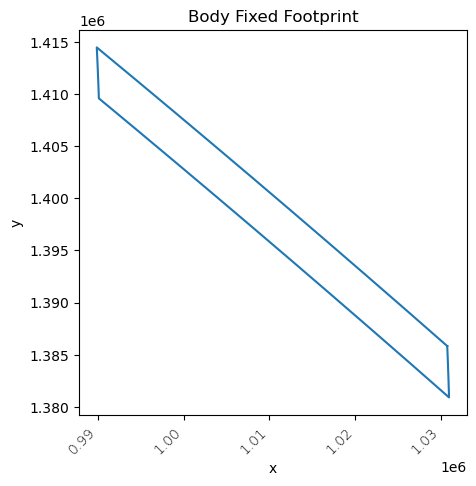

In [17]:
bodyfixed_footprint = csm.generate_bodyfixed_footprint(camera, boundary)

csm_wkt = bodyfixed_footprint.ExportToWkt()

csm_geom = shapely.wkt.loads(csm_wkt)
csm_x, csm_y = csm_geom.geoms[0].exterior.coords.xy

plt.xlabel("x")
plt.ylabel("y")
plt.plot(csm_x, csm_y)
plt.xticks(
    rotation=45, 
    horizontalalignment='right',
    fontweight='light'
)
plt.title("Body Fixed Footprint")


In [ ]:
image_pt = csmapi.ImageCoord(nlines/2, nsamples/2)
shape = Ellipsoid.from_csm_sensor(camera)
illuminator = Illuminator()

caminfo = {
    "PhaseAngle": sensor_utils.phase_angle(image_pt, camera, shape, illuminator),
    "EmissionAngle": sensor_utils.emission_angle(image_pt, camera, shape),
    "SlantDistance": sensor_utils.slant_distance(image_pt, camera, shape),
    "TargetCenterDistance": sensor_utils.target_center_distance(image_pt, camera),
    "SubSpacecraftLatitude": sensor_utils.sub_spacecraft_point(image_pt, camera).lat,
    "SubSpacecraftLongitude": sensor_utils.sub_spacecraft_point(image_pt, camera).lon,
    "LocalRadius": sensor_utils.local_radius(image_pt, camera, shape),
    "RightAscension": sensor_utils.right_ascension_declination(image_pt, camera)[0],
    "Declination": sensor_utils.right_ascension_declination(image_pt, camera)[1],
    "LineResolution": sensor_utils.line_resolution(image_pt, camera, shape),
    "SampleResolution": sensor_utils.sample_resolution(image_pt, camera, shape),
    "PixelResolution": sensor_utils.pixel_resolution(image_pt, camera, shape),
}

caminfo


[2024-09-19 22:34:34.139] [usgscsm_logger] [debug] Accessing ellipsoid radii 1.7374e+06 1.7374e+06
[2024-09-19 22:34:34.140] [usgscsm_logger] [debug] Accessing image time for image point 1000, 752
[2024-09-19 22:34:34.140] [usgscsm_logger] [info] Computing imageToRemoteImagingLocus for 1000, 752 with desired precision 0.001
[2024-09-19 22:34:34.140] [usgscsm_logger] [debug] Accessing sensor position for image point 1000, 752
[2024-09-19 22:34:34.143] [usgscsm_logger] [debug] Accessing illumination direction for ground point 1.01025e+06, 1.39811e+06, -207905
[2024-09-19 22:34:34.143] [usgscsm_logger] [debug] Accessing image time for image point 1000, 752
[2024-09-19 22:34:34.143] [usgscsm_logger] [info] Computing imageToRemoteImagingLocus for 1000, 752 with desired precision 0.001
[2024-09-19 22:34:34.143] [usgscsm_logger] [debug] Accessing sensor position for image point 1000, 752
[2024-09-19 22:34:34.143] [usgscsm_logger] [debug] Accessing image time for image point 1000, 752
[2024-09

{'PhaseAngle': 90.08872593159532,
 'EmissionAngle': 31.496654430210636,
 'SlantDistance': 1428422.3582702668,
 'TargetCenterDistance': 3048141.193593413,
 'SubSpacecraftLatitude': -9.176236457002185,
 'SubSpacecraftLongitude': 68.2720510457321,
 'LocalRadius': 1737400.0,
 'RightAscension': 265.75430662826733,
 'Declination': 11.230208282211784,
 'LineResolution': 21.411014522356215,
 'SampleResolution': 21.411094791187676,
 'PixelResolution': 21.411054656771945}